# Phase 1 — UNSW-NB15 Preprocessing & EDA
**IoT-SecBand | Pipeline position:** UNSW preprocessing → feature selection → model training

This notebook is for exploration and validation only.  
All reusable logic lives in `src/preprocess.py` and `src/eda.py`.

**Inputs:**  
- `data/raw/unsw_nb15/UNSW_NB15_training-set.parquet`  
- `data/raw/unsw_nb15/UNSW_NB15_testing-set.parquet`

**Outputs:**  
- `data/processed/unsw_train_clean.parquet`  
- `data/processed/unsw_test_clean.parquet`  
- `models/scaler_params.json`  
- `models/label_encoders.json`  
- `outputs/eda/*.png`

## 0. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add src/ to path so imports work from notebook
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from preprocess import (
    EDGE_FEATURES, DROPPED_FEATURES, CATEGORICAL_FEATURES,
    load_parquet, audit_columns, clean,
    encode_categoricals, normalize,
    class_balance_report, run_pipeline,
)
from eda import run_eda

%matplotlib inline
plt.rcParams['figure.dpi'] = 130

In [2]:
# ── Paths ───────────────────────────────────────────────────────
# Update these to match your actual file locations
ROOT      = Path.cwd().parent           # project root
RAW_DIR   = ROOT / 'data' / 'raw' / 'unsw_nb15'
PROC_DIR  = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
EDA_DIR   = ROOT / 'outputs' / 'eda'

TRAIN_PATH = RAW_DIR / 'UNSW_NB15_training-set.parquet'
TEST_PATH  = RAW_DIR / 'UNSW_NB15_testing-set.parquet'

# Sanity check
assert TRAIN_PATH.exists(), f'Training file not found: {TRAIN_PATH}'
assert TEST_PATH.exists(),  f'Test file not found: {TEST_PATH}'
print('Files found. Paths OK.')

Files found. Paths OK.


## 1. Load & Inspect Raw Data

In [3]:
df_raw_train = load_parquet(TRAIN_PATH)
df_raw_test  = load_parquet(TEST_PATH)

print(f'\nTraining shape: {df_raw_train.shape}')
print(f'Test shape:     {df_raw_test.shape}')

INFO | Loaded: UNSW_NB15_training-set.parquet — shape=(175341, 36)
INFO | Class distribution:
label
1    119341
0     56000
INFO | Loaded: UNSW_NB15_testing-set.parquet — shape=(82332, 36)
INFO | Class distribution:
label
1    45332
0    37000



Training shape: (175341, 36)
Test shape:     (82332, 36)


In [4]:
# Inspect dtypes and first few rows
print('Dtypes:')
print(df_raw_train.dtypes.to_string())
df_raw_train.head(3)

Dtypes:
dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd         int8
is

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0


In [5]:
# Null audit on raw data
null_summary = df_raw_train.isnull().sum()
print('Null counts (raw training set):')
print(null_summary[null_summary > 0].to_string() or 'None')

Null counts (raw training set):
Series([], )


## 2. Column Audit — Edge Deployability

In [6]:
audit = audit_columns(df_raw_train)

print(f"Features to KEEP ({len(audit['present_expected'])}):")
print(audit['present_expected'])

print(f"\nFeatures to DROP ({len(audit['present_dropped'])}):")
print(audit['present_dropped'])

if audit['missing_expected']:
    print(f"\nWARNING — Missing expected features: {audit['missing_expected']}")

Features to KEEP (18):
['dbytes', 'dinpkt', 'dload', 'dloss', 'dmean', 'dpkts', 'dur', 'label', 'proto', 'rate', 'sbytes', 'service', 'sinpkt', 'sload', 'sloss', 'smean', 'spkts', 'state']

Features to DROP (18):
['ackdat', 'attack_cat', 'ct_dst_sport_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm', 'djit', 'dtcpb', 'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'response_body_len', 'sjit', 'stcpb', 'swin', 'synack', 'tcprtt', 'trans_depth']


## 3. Class Balance Check

In [7]:
# Check on raw data before any processing
balance = class_balance_report(df_raw_train)

print(f"Class counts:      {balance['counts']}")
print(f"Class percentages: {balance['percentages']}")
print(f"Imbalance ratio:   {balance['imbalance_ratio']}")
print(f"Recommend SMOTE:   {balance['recommend_smote']}")

# Key question: is your 86% accuracy from imbalance or bad features?
# If attack class is < 30% of data and your model has low attack-class F1,
# imbalance is the primary cause — not the model.
attack_pct = balance['percentages'].get(1, 0)
print(f"\nAttack samples: {attack_pct:.1f}% of training set")
if attack_pct < 30:
    print('NOTE: Attack class underrepresented. Check F1 on attack class specifically.')

INFO | Class balance — counts: {0: 56000, 1: 119341}, ratio: 2.13


Class counts:      {0: 56000, 1: 119341}
Class percentages: {0: 31.94, 1: 68.06}
Imbalance ratio:   2.13
Recommend SMOTE:   False

Attack samples: 68.1% of training set


## 4. Attack Category Breakdown
Understand what types of attacks exist before dropping `attack_cat`.

In [8]:
if 'attack_cat' in df_raw_train.columns:
    cat_counts = df_raw_train['attack_cat'].value_counts()
    print('Attack category distribution (raw):')
    print(cat_counts.to_string())
    
    # Cross-check: all label=1 rows should have a non-Normal attack_cat
    attack_rows = df_raw_train[df_raw_train['label'] == 1]
    normal_rows = df_raw_train[df_raw_train['label'] == 0]
    print(f'\nlabel=1 rows: {len(attack_rows):,} | label=0 rows: {len(normal_rows):,}')

Attack category distribution (raw):
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130

label=1 rows: 119,341 | label=0 rows: 56,000


## 5. Categorical Feature Inspection
Check cardinality of proto, service, state before encoding.

In [9]:
for col in CATEGORICAL_FEATURES:
    if col in df_raw_train.columns:
        uniq = df_raw_train[col].nunique()
        top5 = df_raw_train[col].value_counts().head(5)
        print(f"\n{col} — {uniq} unique values. Top 5:")
        print(top5.to_string())


proto — 133 unique values. Top 5:
proto
tcp     79946
udp     63283
unas    12084
arp      2859
ospf     2595

service — 13 unique values. Top 5:
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995

state — 9 unique values. Top 5:
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83


## 6. Run Full Preprocessing Pipeline

In [10]:
result = run_pipeline(
    train_path    = TRAIN_PATH,
    test_path     = TEST_PATH,
    output_dir    = PROC_DIR,
    artifacts_dir = MODEL_DIR,
)

print('\n── Pipeline complete ──')
print(f"Train: {result['train_shape']}  →  {result['train_output']}")
print(f"Test:  {result['test_shape']}   →  {result['test_output']}")
print(f"Features used ({len(result['features_used'])}): {result['features_used']}")

INFO | ==================================================
INFO | STEP 1/6 — Load raw data
INFO | Loaded: UNSW_NB15_training-set.parquet — shape=(175341, 36)
INFO | Class distribution:
label
1    119341
0     56000
INFO | Loaded: UNSW_NB15_testing-set.parquet — shape=(82332, 36)
INFO | Class distribution:
label
1    45332
0    37000
INFO | ==================================================
INFO | STEP 2/6 — Audit columns
INFO | Audit: 18 expected features present
INFO | ==================================================
INFO | STEP 3/6 — Clean
INFO | Selected 18 columns (incl. target)
INFO | Dropped 86251 duplicate rows
INFO | No null values found
INFO | Clean complete — shape=(89090, 18)
INFO | Selected 18 columns (incl. target)
INFO | Dropped 35941 duplicate rows
INFO | No null values found
INFO | Clean complete — shape=(46391, 18)
INFO | ==================================================
INFO | STEP 4/6 — Class balance
INFO | Class balance — counts: {0: 47537, 1: 41553}, ratio: 1.14



── Pipeline complete ──
Train: (89090, 18)  →  d:\IoT-Research-Project\data\processed\unsw_train_clean.parquet
Test:  (46391, 18)   →  d:\IoT-Research-Project\data\processed\unsw_test_clean.parquet
Features used (17): ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'smean', 'dmean']


## 7. Validate Processed Output

In [11]:
# Reload from parquet — confirm nothing was lost in save/load cycle
df_train = pd.read_parquet(result['train_output'])
df_test  = pd.read_parquet(result['test_output'])

print('Processed training set:')
print(df_train.dtypes)
print(f'\nNull count: {df_train.isnull().sum().sum()}')
print(f'Inf count:  {np.isinf(df_train.select_dtypes(include=np.number)).sum().sum()}')
df_train.describe().round(3)

Processed training set:
dur        float64
proto      float64
service    float64
state      float64
spkts      float64
dpkts      float64
sbytes     float64
dbytes     float64
rate       float64
sload      float64
dload      float64
sloss      float64
dloss      float64
sinpkt     float64
dinpkt     float64
smean      float64
dmean      float64
label        int32
dtype: object

Null count: 0
Inf count:  0


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,smean,dmean,label
count,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000,89090.000
mean,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.466
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.499
min,-0.274,-13.329,-0.725,-2.513,-0.182,-0.246,-0.067,-0.148,-0.175,-0.141,-0.397,-0.103,-0.188,-0.090,-0.106,-0.587,-0.731,0.000
25%,-0.267,-0.008,-0.725,0.221,-0.135,-0.205,-0.065,-0.146,-0.174,-0.141,-0.396,-0.082,-0.174,-0.089,-0.105,-0.468,-0.590,0.000
50%,-0.172,-0.008,-0.725,0.221,-0.124,-0.178,-0.063,-0.144,-0.174,-0.141,-0.393,-0.082,-0.160,-0.080,-0.071,-0.380,-0.475,0.000
75%,-0.067,-0.008,0.974,0.221,-0.040,-0.082,-0.055,-0.126,-0.140,-0.138,-0.200,-0.027,-0.074,-0.065,-0.026,-0.189,-0.020,1.000
max,11.490,2.232,3.352,8.423,50.397,74.706,52.916,76.210,18.610,32.869,6.453,51.917,77.959,25.257,48.435,5.062,3.812,1.000


In [12]:
# Confirm label distribution is preserved
print('Training label distribution (processed):')
print(df_train['label'].value_counts().to_string())

print('\nTest label distribution (processed):')
print(df_test['label'].value_counts().to_string())

Training label distribution (processed):
label
0    47537
1    41553

Test label distribution (processed):
label
0    30787
1    15604


## 8. EDA — Exploratory Data Analysis
All plots saved to `outputs/eda/`. View them in the outputs folder.

In [13]:
eda_paths = run_eda(df_train, save_dir=EDA_DIR)

print('\nEDA outputs:')
for name, path in eda_paths.items():
    print(f'  {name}: {path}')

INFO | Running EDA — saving to d:\IoT-Research-Project\outputs\eda
INFO | Saved: d:\IoT-Research-Project\outputs\eda\01_class_distribution.png
INFO | Saved: d:\IoT-Research-Project\outputs\eda\02_feature_distributions.png
INFO | Saved: d:\IoT-Research-Project\outputs\eda\03_correlation_heatmap.png
INFO | Outlier report — top 5:
feature      q1      q3    iqr  n_outliers  outlier_pct
  dmean -0.5904 -0.0202 0.5702       17910        20.10
 dbytes -0.1465 -0.1256 0.0209       15998        17.96
  state  0.2210  0.2210 0.0000       14986        16.82
  proto -0.0080 -0.0080 0.0000       13539        15.20
  smean -0.4679 -0.1886 0.2793       13497        15.15
INFO | Saved: d:\IoT-Research-Project\outputs\eda\04_outlier_summary.png
INFO | Saved: d:\IoT-Research-Project\outputs\eda\05_mutual_info.png
INFO | EDA complete — 5 plots saved to d:\IoT-Research-Project\outputs\eda



EDA outputs:
  class_distribution: d:\IoT-Research-Project\outputs\eda\01_class_distribution.png
  feature_distributions: d:\IoT-Research-Project\outputs\eda\02_feature_distributions.png
  correlation_heatmap: d:\IoT-Research-Project\outputs\eda\03_correlation_heatmap.png
  outlier_summary: d:\IoT-Research-Project\outputs\eda\04_outlier_summary.png
  mutual_info: d:\IoT-Research-Project\outputs\eda\05_mutual_info.png



── class_distribution ──


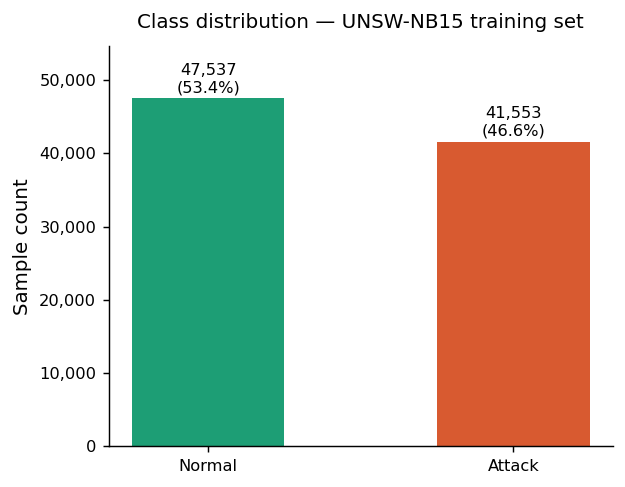


── feature_distributions ──


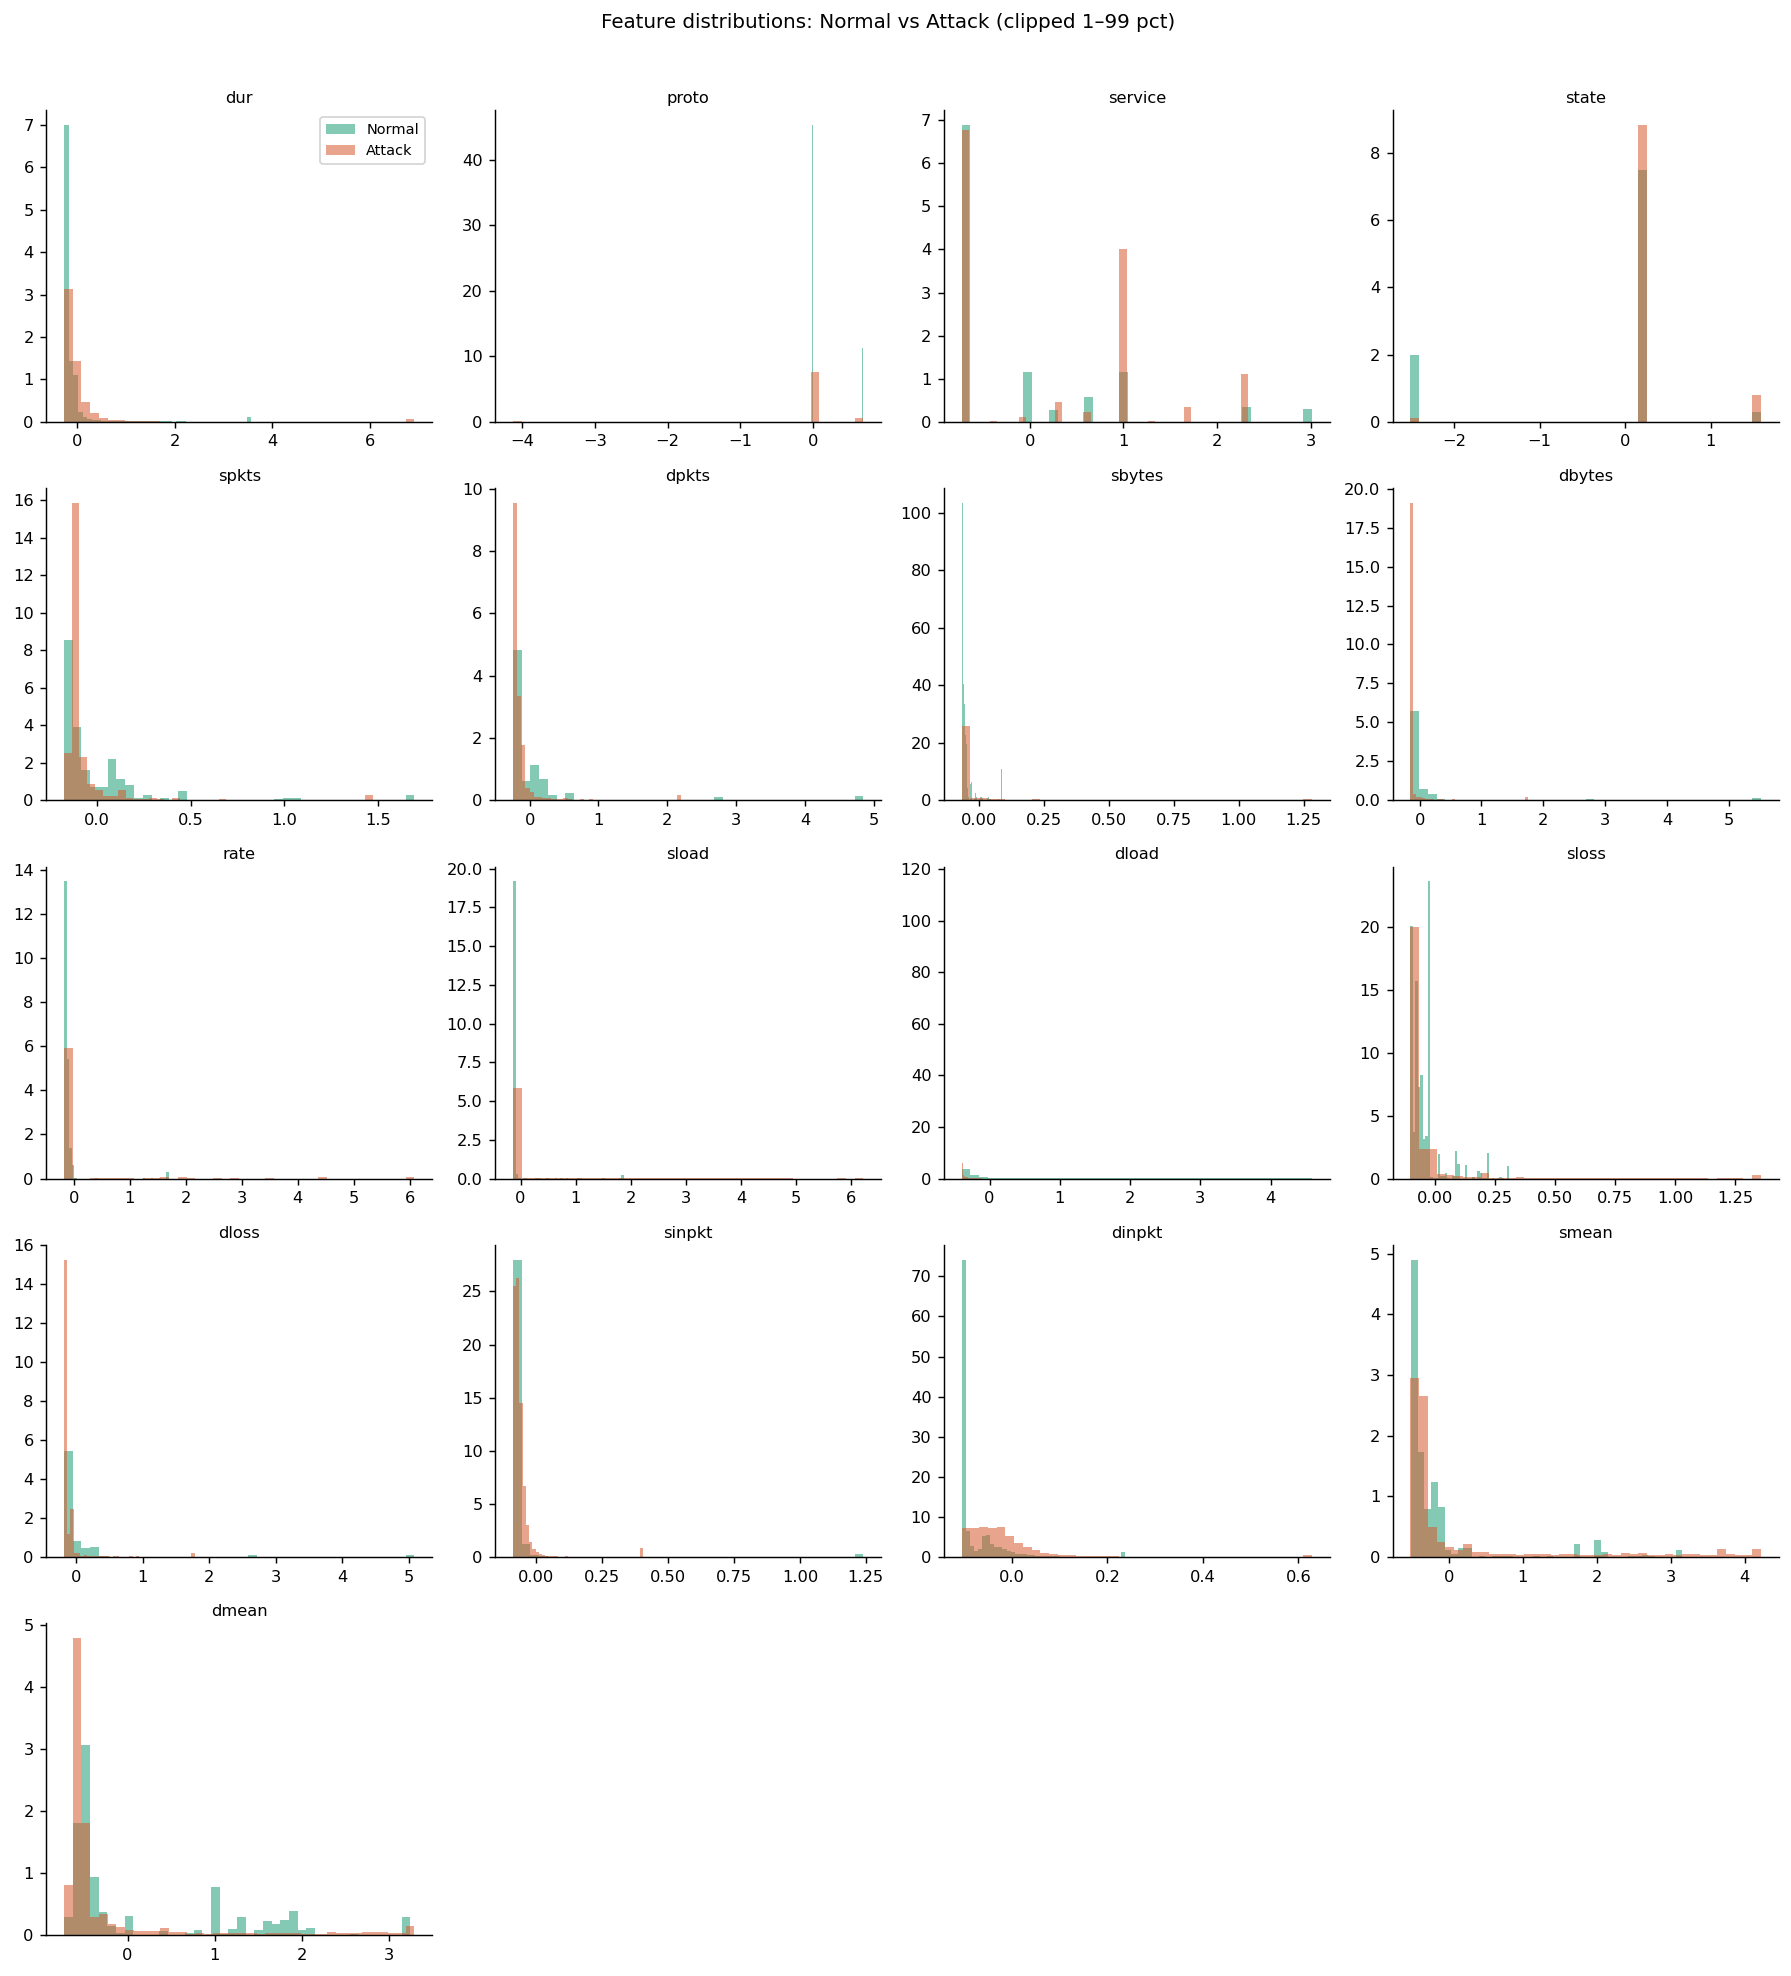


── correlation_heatmap ──


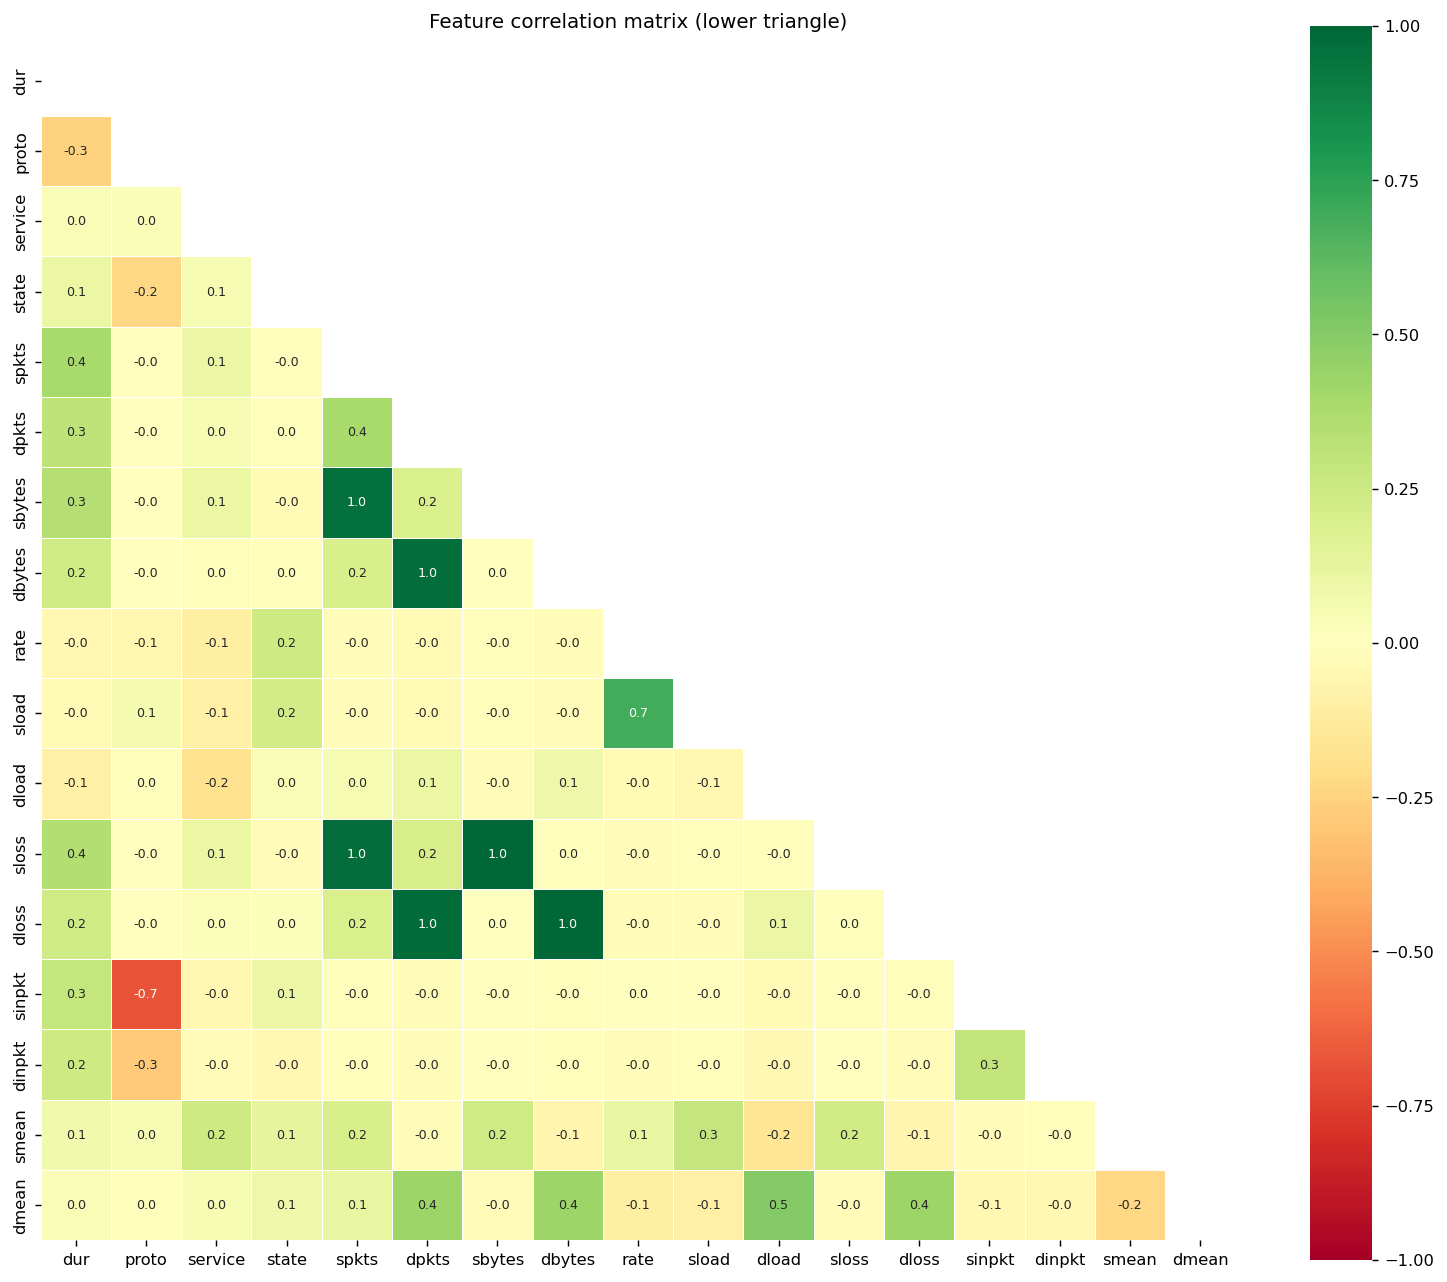


── outlier_summary ──


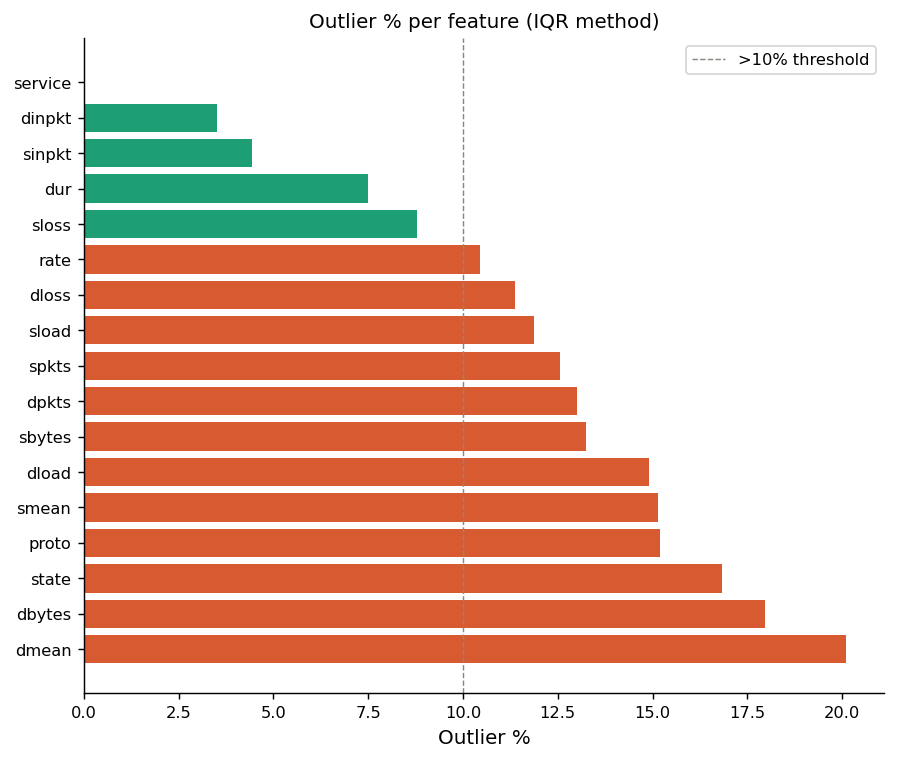


── mutual_info ──


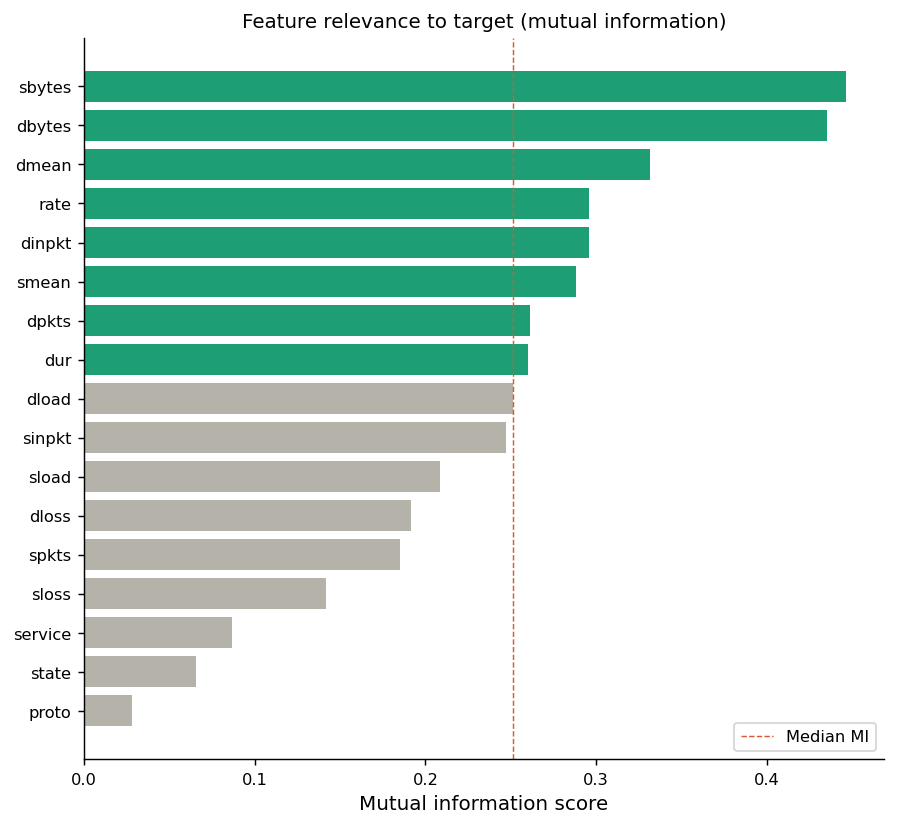

In [14]:
# Display plots inline for quick review
from IPython.display import display, Image
for name, path in eda_paths.items():
    print(f'\n── {name} ──')
    display(Image(path, width=750))

## 9. Highly Correlated Feature Pairs
Detect redundant features (|r| > 0.90) — candidates for removal to further shrink model input size.

In [15]:
numeric_cols = [c for c in df_train.select_dtypes(include=np.number).columns if c != 'label']
corr = df_train[numeric_cols].corr().abs()

# Upper triangle mask
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, row, round(upper.loc[row, col], 3))
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.90
]

print(f'Feature pairs with |r| > 0.90 ({len(high_corr_pairs)} found):')
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f'  {f1:20s} <-> {f2:20s}   r={r}')
    
if not high_corr_pairs:
    print('None found — feature set is non-redundant.')
else:
    print('\nConsider dropping one from each pair to reduce model input size.')

Feature pairs with |r| > 0.90 (6 found):
  sloss                <-> sbytes                 r=0.997
  dloss                <-> dbytes                 r=0.997
  dloss                <-> dpkts                  r=0.977
  sloss                <-> spkts                  r=0.975
  dbytes               <-> dpkts                  r=0.971
  sbytes               <-> spkts                  r=0.968

Consider dropping one from each pair to reduce model input size.


## 10. Phase 1 Summary
Record your findings before moving to Phase 2.

In [29]:
import json

summary = {
    'phase':           '1 — UNSW-NB15 Preprocessing',
    'train_shape_raw': list(df_raw_train.shape),
    'train_shape_clean': list(df_train.shape),
    'test_shape_clean':  list(df_test.shape),
    'n_features':        len(result['features_used']),
    'features':          result['features_used'],
    'class_balance':     result['balance_report'],
    'high_corr_pairs':   [(f1, f2, r) for f1, f2, r in high_corr_pairs],
    'outputs': {
        'train_parquet':   result['train_output'],
        'test_parquet':    result['test_output'],
        'scaler_params':   result['scaler_path'],
        'label_encoders':  result['encoder_path'],
        'eda_plots':       eda_paths,
    }
}

summary_path = Path('../outputs') / 'phase1_summary.json'
summary_path.parent.mkdir(parents=True, exist_ok=True)
# Ensure the updated preprocess module (with sanitizer) is loaded
import importlib
import preprocess
importlib.reload(preprocess)
with open(summary_path, 'w') as f:
    json.dump(preprocess._to_json_serializable(summary), f, indent=2)

print(json.dumps(preprocess._to_json_serializable(summary), indent=2))

{
  "phase": "1 \u2014 UNSW-NB15 Preprocessing",
  "train_shape_raw": [
    175341,
    36
  ],
  "train_shape_clean": [
    89090,
    18
  ],
  "test_shape_clean": [
    46391,
    18
  ],
  "n_features": 17,
  "features": [
    "dur",
    "proto",
    "service",
    "state",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
    "rate",
    "sload",
    "dload",
    "sloss",
    "dloss",
    "sinpkt",
    "dinpkt",
    "smean",
    "dmean"
  ],
  "class_balance": {
    "counts": {
      "0": 47537,
      "1": 41553
    },
    "percentages": {
      "0": 53.36,
      "1": 46.64
    },
    "imbalance_ratio": 1.14,
    "recommend_smote": false
  },
  "high_corr_pairs": [
    [
      "sbytes",
      "spkts",
      0.968
    ],
    [
      "dbytes",
      "dpkts",
      0.971
    ],
    [
      "sloss",
      "spkts",
      0.975
    ],
    [
      "sloss",
      "sbytes",
      0.997
    ],
    [
      "dloss",
      "dpkts",
      0.977
    ],
    [
      "dloss",
      "dbytes",
  

---
**Next:** `02_model_training.ipynb` — Phase 2: binary classifier on clean features.

**Before proceeding, check:**
1. Is imbalance ratio > 3:1? → Enable SMOTE in Phase 2 notebook.
2. Are any feature pairs |r| > 0.90? → Drop the one with lower MI score.
3. Do the distributions in plot 02 show clear separation? → Those features are your strongest signals.
4. Any features with >10% outliers in plot 04? → Apply robust scaling in Phase 2 if needed.